Number of communities: 3
Total number of nodes (colleges): 31

Community 0: ['29', '26', '19', '14', '10', '12', '18', '16', '17', '25', '30', '7', '11', '13', '20', '9', '28', '15']
Community 1: ['4', '6', '3', '22', '2', '8', '5', '27', '23', '1', '0']
Community 2: ['21', '24']

Modularity: 0.32676911157024796
Coverage: 0.7842105263157895
Performance: 0.7827956989247312


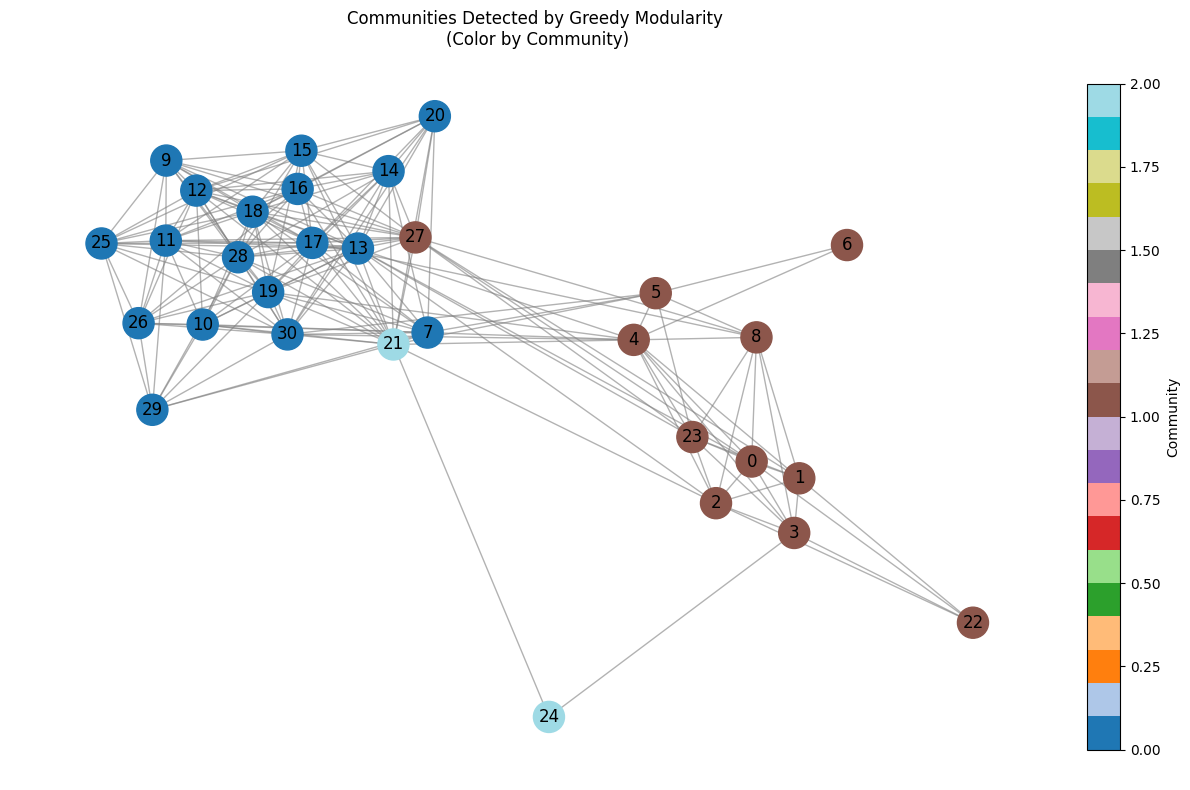

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from networkx.algorithms.community import greedy_modularity_communities, modularity

# 读取图数据（带权重）
G = nx.read_weighted_edgelist('courses1.txt')
G = G.to_undirected()

# 度中心性（基于无权重连接数，这是标准定义）
degree_centrality = nx.degree_centrality(G)

# === 使用贪心模块度最大化算法（支持权重）===
communities = list(greedy_modularity_communities(G))

# 构建 community_map: node -> community_id
community_map = {}
for comm_id, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_id

# 打印基本信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 打印每个社区包含的节点
for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# 计算模块度（注意：modularity 函数也要传 weight）
modularity_value = modularity(G, communities, weight='weight')
print(f"Modularity: {modularity_value}")

# 覆盖度（Coverage）：社区内部边占总边的比例
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 表现评分（Performance）
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges_set = set(tuple(sorted(e)) for e in G.edges())
    
    # 实际内部边
    intra_edges = sum(1 for u, v in actual_edges_set if community_map[u] == community_map[v])
    inter_edges = len(actual_edges_set) - intra_edges
    
    # 可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # 正确预测 = 存在的内部边 + 不存在的外部边
    missing_inter_edges = possible_inter_edges - inter_edges
    correct_predictions = intra_edges + missing_inter_edges
    
    return correct_predictions / total_possible_edges if total_possible_edges > 0 else 0

performance_value = compute_performance(G, communities, community_map)
print(f"Performance: {performance_value}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 节点颜色按社区 ID
community_colors = [community_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Greedy Modularity \n(Color by Community)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 3
Total number of nodes (colleges): 30

Community 0: ['12', '18', '16', '17', '27', '11', '13', '20', '9', '28', '14', '15']
Community 1: ['4', '6', '29', '26', '21', '25', '19', '30', '5', '8', '7', '10']
Community 2: ['23', '1', '3', '0', '22', '2']

Modularity: 0.43086673178474405
Coverage: 0.7622950819672131
Performance: 0.8091954022988506


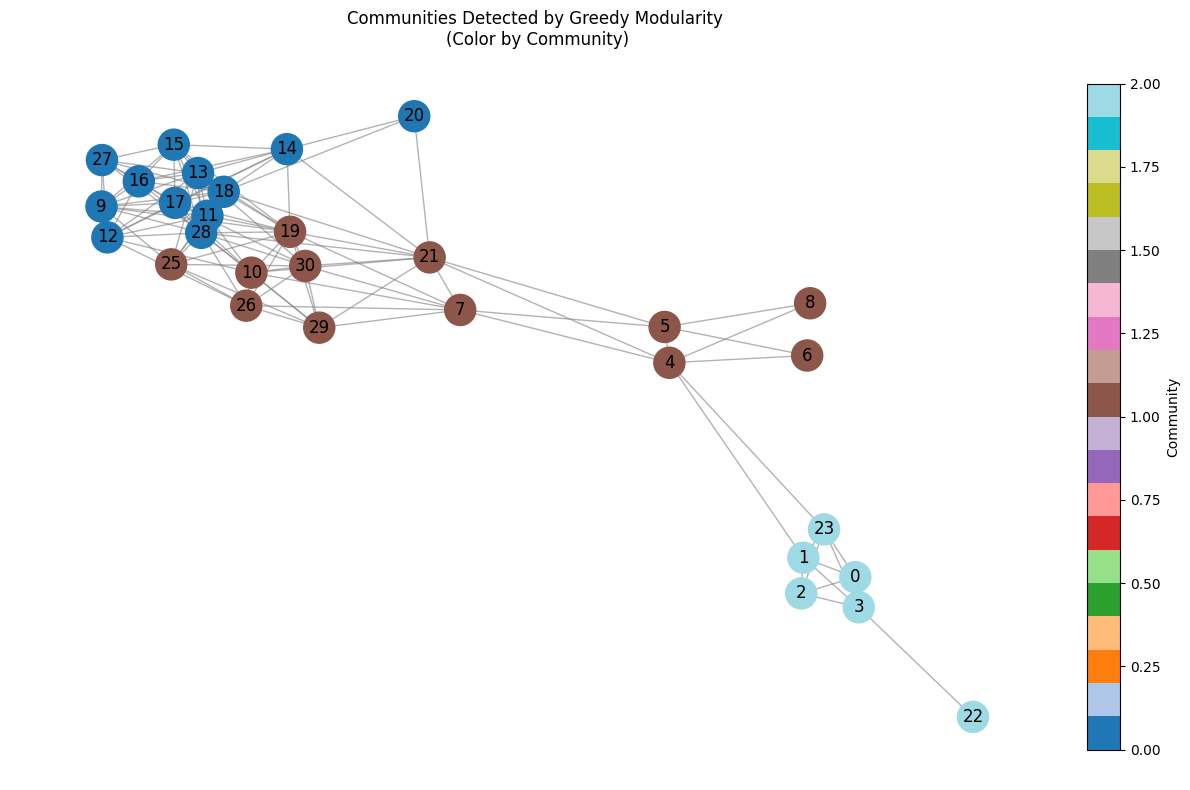

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from networkx.algorithms.community import greedy_modularity_communities, modularity

# 读取图数据（带权重）
G = nx.read_weighted_edgelist('courses2.txt')
G = G.to_undirected()

# 度中心性（基于无权重连接数，这是标准定义）
degree_centrality = nx.degree_centrality(G)

# === 使用贪心模块度最大化算法（支持权重）===
communities = list(greedy_modularity_communities(G))

# 构建 community_map: node -> community_id
community_map = {}
for comm_id, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_id

# 打印基本信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 打印每个社区包含的节点
for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# 计算模块度（注意：modularity 函数也要传 weight）
modularity_value = modularity(G, communities, weight='weight')
print(f"Modularity: {modularity_value}")

# 覆盖度（Coverage）：社区内部边占总边的比例
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 表现评分（Performance）
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges_set = set(tuple(sorted(e)) for e in G.edges())
    
    # 实际内部边
    intra_edges = sum(1 for u, v in actual_edges_set if community_map[u] == community_map[v])
    inter_edges = len(actual_edges_set) - intra_edges
    
    # 可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # 正确预测 = 存在的内部边 + 不存在的外部边
    missing_inter_edges = possible_inter_edges - inter_edges
    correct_predictions = intra_edges + missing_inter_edges
    
    return correct_predictions / total_possible_edges if total_possible_edges > 0 else 0

performance_value = compute_performance(G, communities, community_map)
print(f"Performance: {performance_value}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 节点颜色按社区 ID
community_colors = [community_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Greedy Modularity \n(Color by Community)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 29

Community 0: ['12', '18', '26', '28', '25', '30', '19', '13', '9', '11', '10']
Community 1: ['23', '1', '3', '0', '22', '2']
Community 2: ['27', '16', '20', '17', '14', '15']
Community 3: ['4', '7', '6', '21', '8', '5']

Modularity: 0.4274044002825699
Coverage: 0.7272727272727273
Performance: 0.9351351351351351


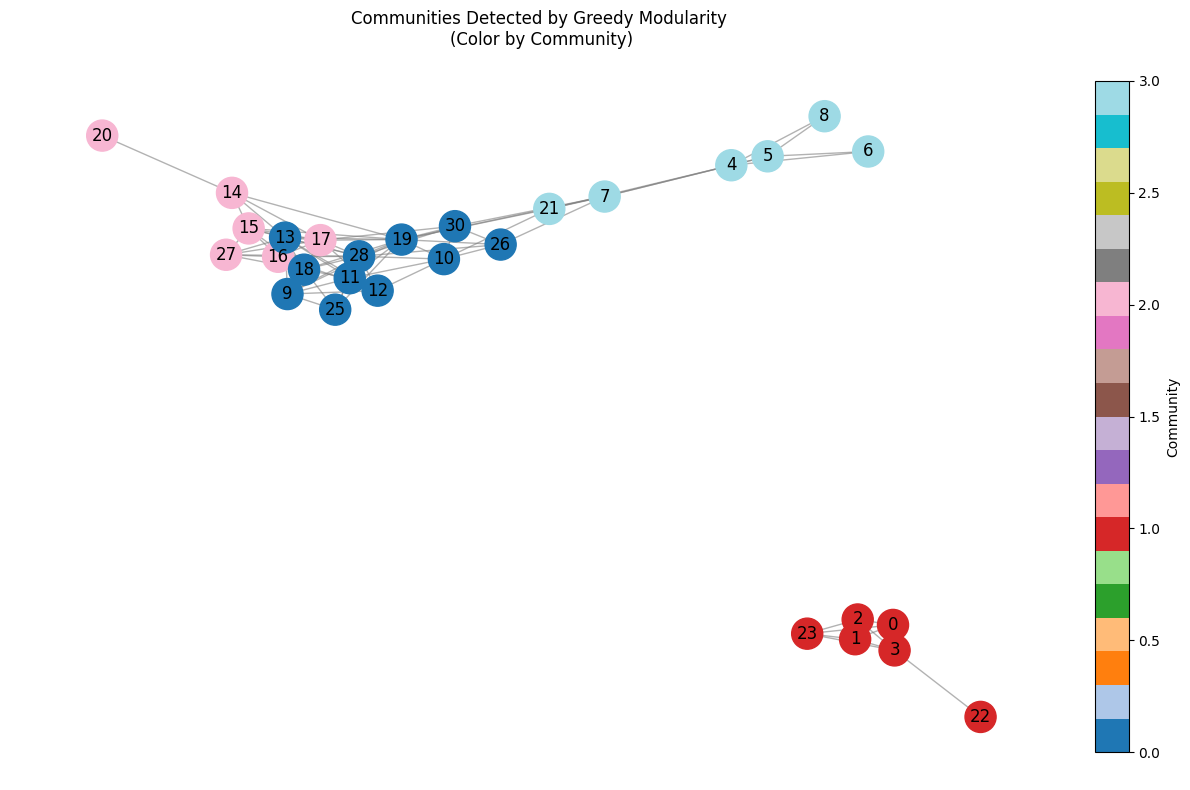

In [7]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from networkx.algorithms.community import greedy_modularity_communities, modularity

# 读取图数据（带权重）
G = nx.read_weighted_edgelist('courses3.txt')
G = G.to_undirected()

# 度中心性（基于无权重连接数，这是标准定义）
degree_centrality = nx.degree_centrality(G)

# === 使用贪心模块度最大化算法（支持权重）===
communities = list(greedy_modularity_communities(G))

# 构建 community_map: node -> community_id
community_map = {}
for comm_id, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_id

# 打印基本信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 打印每个社区包含的节点
for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# 计算模块度（注意：modularity 函数也要传 weight）
modularity_value = modularity(G, communities, weight='weight')
print(f"Modularity: {modularity_value}")

# 覆盖度（Coverage）：社区内部边占总边的比例
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 手动实现表现评分
def compute_performance(G, communities):
    intra_edges = sum(1 for edge in G.edges() if community_map[edge[0]] == community_map[edge[1]])
    inter_edges = sum(1 for edge in G.edges() if community_map[edge[0]] != community_map[edge[1]])
    possible_intra_edges = sum(len(community) * (len(community) - 1) / 2 for community in communities)
    possible_inter_edges = len(G.nodes()) * (len(G.nodes()) - 1) / 2 - possible_intra_edges
    return (intra_edges + possible_inter_edges - inter_edges) / (intra_edges + inter_edges + possible_inter_edges - inter_edges)

performance_value = compute_performance(G, communities)
print(f"Performance: {performance_value}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 节点颜色按社区 ID
community_colors = [community_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Greedy Modularity \n(Color by Community)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 28

Community 0: ['12', '18', '26', '17', '25', '30', '19', '11', '9', '28', '10']
Community 1: ['27', '13', '16', '20', '14', '15']
Community 2: ['4', '7', '6', '21', '8', '5']
Community 3: ['23', '1', '3', '0', '2']

Modularity: 0.4711385834300935
Coverage: 0.7746478873239436
Performance: 0.8518518518518519


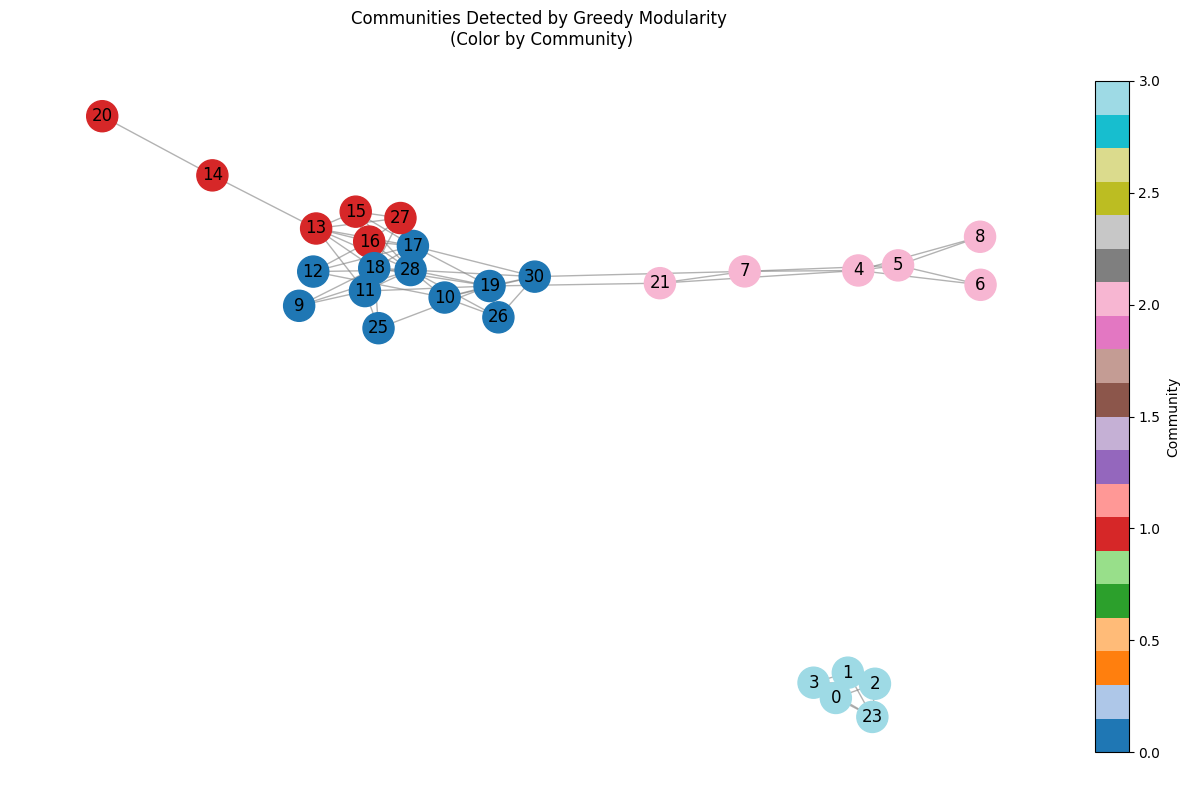

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from networkx.algorithms.community import greedy_modularity_communities, modularity

# 读取图数据（带权重）
G = nx.read_weighted_edgelist('courses4.txt')
G = G.to_undirected()

# 度中心性（基于无权重连接数，这是标准定义）
degree_centrality = nx.degree_centrality(G)

# === 使用贪心模块度最大化算法（支持权重）===
communities = list(greedy_modularity_communities(G))

# 构建 community_map: node -> community_id
community_map = {}
for comm_id, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_id

# 打印基本信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 打印每个社区包含的节点
for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# 计算模块度（注意：modularity 函数也要传 weight）
modularity_value = modularity(G, communities, weight='weight')
print(f"Modularity: {modularity_value}")

# 覆盖度（Coverage）：社区内部边占总边的比例
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 表现评分（Performance）
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges_set = set(tuple(sorted(e)) for e in G.edges())
    
    # 实际内部边
    intra_edges = sum(1 for u, v in actual_edges_set if community_map[u] == community_map[v])
    inter_edges = len(actual_edges_set) - intra_edges
    
    # 可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # 正确预测 = 存在的内部边 + 不存在的外部边
    missing_inter_edges = possible_inter_edges - inter_edges
    correct_predictions = intra_edges + missing_inter_edges
    
    return correct_predictions / total_possible_edges if total_possible_edges > 0 else 0

performance_value = compute_performance(G, communities, community_map)
print(f"Performance: {performance_value}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 节点颜色按社区 ID
community_colors = [community_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Greedy Modularity \n(Color by Community)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 5
Total number of nodes (colleges): 26

Community 0: ['12', '18', '26', '25', '30', '19', '11', '9', '28', '10']
Community 1: ['27', '13', '16', '17', '14', '15']
Community 2: ['23', '1', '3', '0', '2']
Community 3: ['4', '6', '5']
Community 4: ['21', '7']

Modularity: 0.4969777777777778
Coverage: 0.803921568627451
Performance: 0.8676923076923077


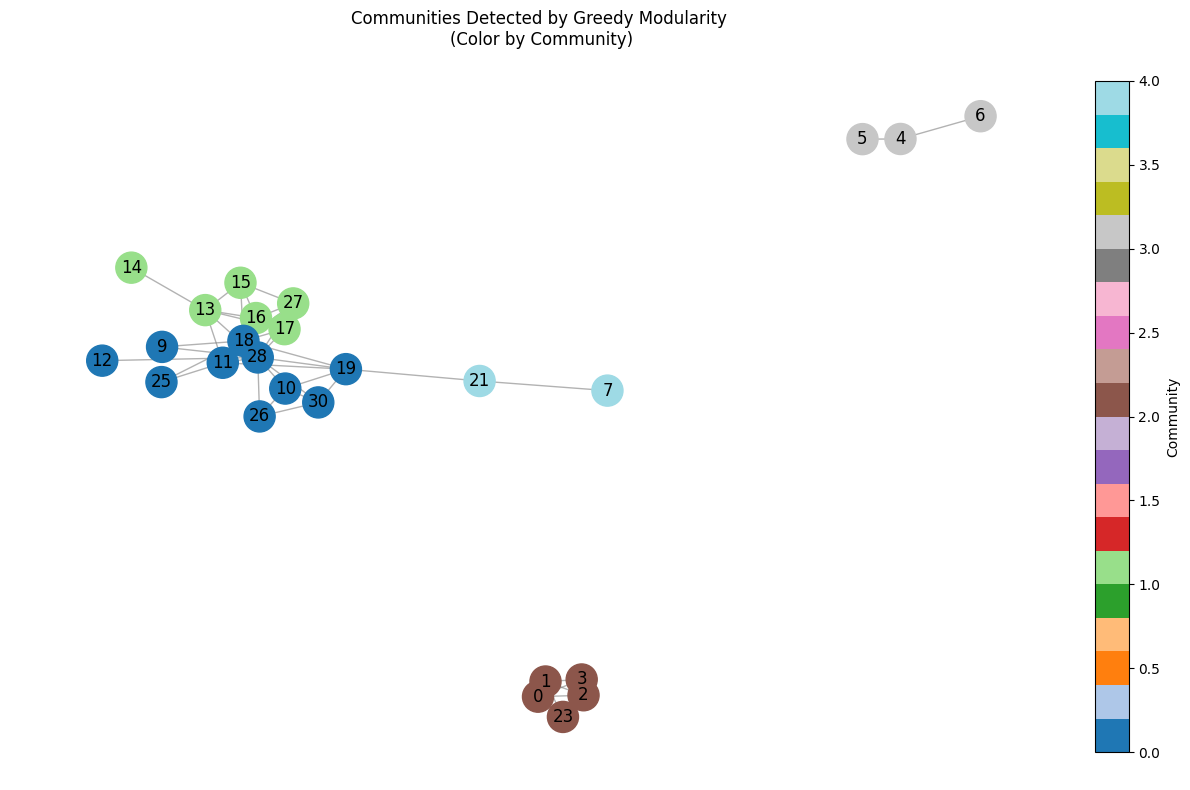

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from networkx.algorithms.community import greedy_modularity_communities, modularity

# 读取图数据（带权重）
G = nx.read_weighted_edgelist('courses5.txt')
G = G.to_undirected()

# 度中心性（基于无权重连接数，这是标准定义）
degree_centrality = nx.degree_centrality(G)

# === 使用贪心模块度最大化算法（支持权重）===
communities = list(greedy_modularity_communities(G))

# 构建 community_map: node -> community_id
community_map = {}
for comm_id, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_id

# 打印基本信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 打印每个社区包含的节点
for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# 计算模块度（注意：modularity 函数也要传 weight）
modularity_value = modularity(G, communities, weight='weight')
print(f"Modularity: {modularity_value}")

# 覆盖度（Coverage）：社区内部边占总边的比例
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 表现评分（Performance）
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges_set = set(tuple(sorted(e)) for e in G.edges())
    
    # 实际内部边
    intra_edges = sum(1 for u, v in actual_edges_set if community_map[u] == community_map[v])
    inter_edges = len(actual_edges_set) - intra_edges
    
    # 可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # 正确预测 = 存在的内部边 + 不存在的外部边
    missing_inter_edges = possible_inter_edges - inter_edges
    correct_predictions = intra_edges + missing_inter_edges
    
    return correct_predictions / total_possible_edges if total_possible_edges > 0 else 0

performance_value = compute_performance(G, communities, community_map)
print(f"Performance: {performance_value}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 节点颜色按社区 ID
community_colors = [community_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Greedy Modularity \n(Color by Community)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 3
Total number of nodes (colleges): 31

Community 0: ['14', '28', '16', '13', '18', '12', '19', '27', '11', '17', '15', '9', '25', '10', '20', '26', '30']
Community 1: ['7', '6', '21', '8', '4', '24', '29', '5']
Community 2: ['22', '2', '0', '23', '1', '3']

Modularity: 0.3898876709009285
Coverage: 0.7105263157894737
Performance: 0.7870967741935484


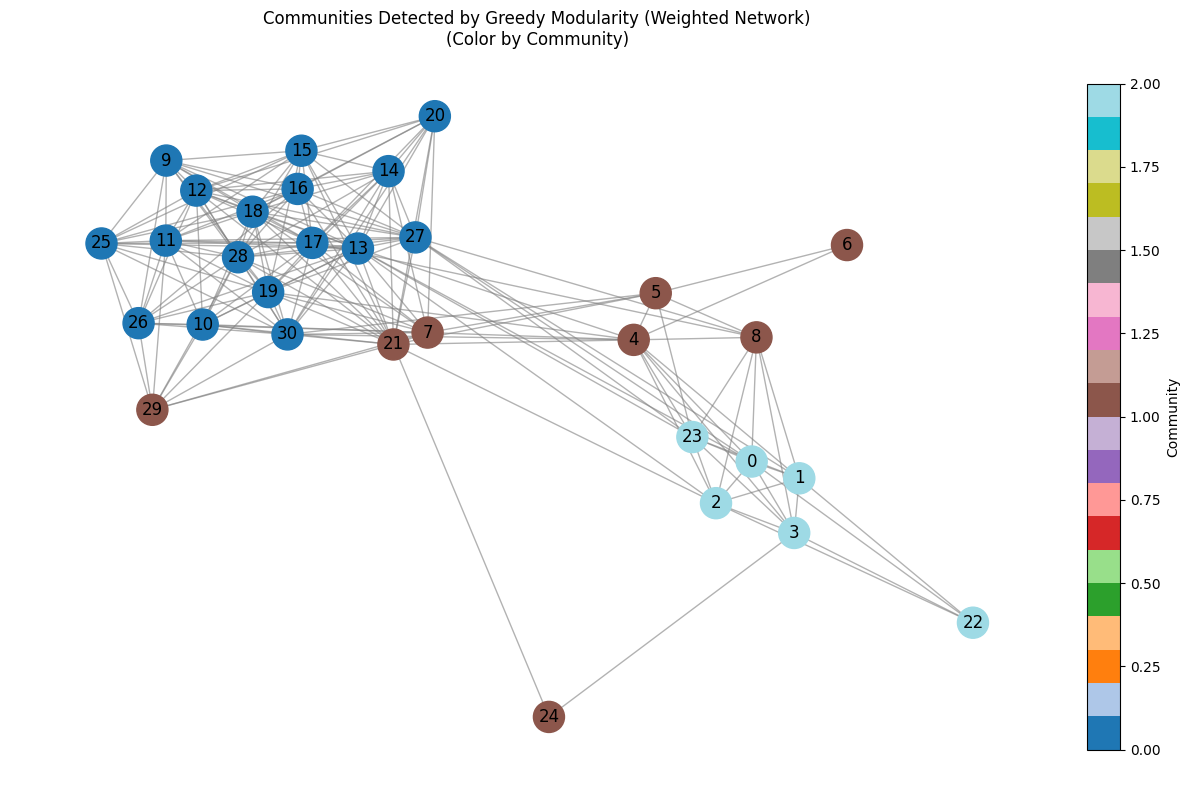

In [25]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from networkx.algorithms.community import greedy_modularity_communities, modularity

# 读取图数据（带权重）
G = nx.read_weighted_edgelist('courses1.txt')
G = G.to_undirected()

# 度中心性（基于无权重连接数，这是标准定义）
degree_centrality = nx.degree_centrality(G)

# === 使用贪心模块度最大化算法（支持权重）===
communities = list(greedy_modularity_communities(G, weight='weight'))

# 构建 community_map: node -> community_id
community_map = {}
for comm_id, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_id

# 打印基本信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 打印每个社区包含的节点
for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# 计算模块度（注意：modularity 函数也要传 weight）
modularity_value = modularity(G, communities, weight='weight')
print(f"Modularity: {modularity_value}")

# 覆盖度（Coverage）：社区内部边占总边的比例
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 表现评分（Performance）
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges_set = set(tuple(sorted(e)) for e in G.edges())
    
    # 实际内部边
    intra_edges = sum(1 for u, v in actual_edges_set if community_map[u] == community_map[v])
    inter_edges = len(actual_edges_set) - intra_edges
    
    # 可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # 正确预测 = 存在的内部边 + 不存在的外部边
    missing_inter_edges = possible_inter_edges - inter_edges
    correct_predictions = intra_edges + missing_inter_edges
    
    return correct_predictions / total_possible_edges if total_possible_edges > 0 else 0

performance_value = compute_performance(G, communities, community_map)
print(f"Performance: {performance_value}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 节点颜色按社区 ID
community_colors = [community_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Greedy Modularity (Weighted Network)\n(Color by Community)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 30

Community 0: ['14', '27', '28', '11', '17', '16', '15', '9', '13', '18', '10', '20', '12']
Community 1: ['25', '29', '19', '7', '26', '21', '30']
Community 2: ['22', '2', '0', '23', '1', '3']
Community 3: ['6', '8', '4', '5']

Modularity: 0.431034614328012
Coverage: 0.7131147540983607
Performance: 0.8436781609195402


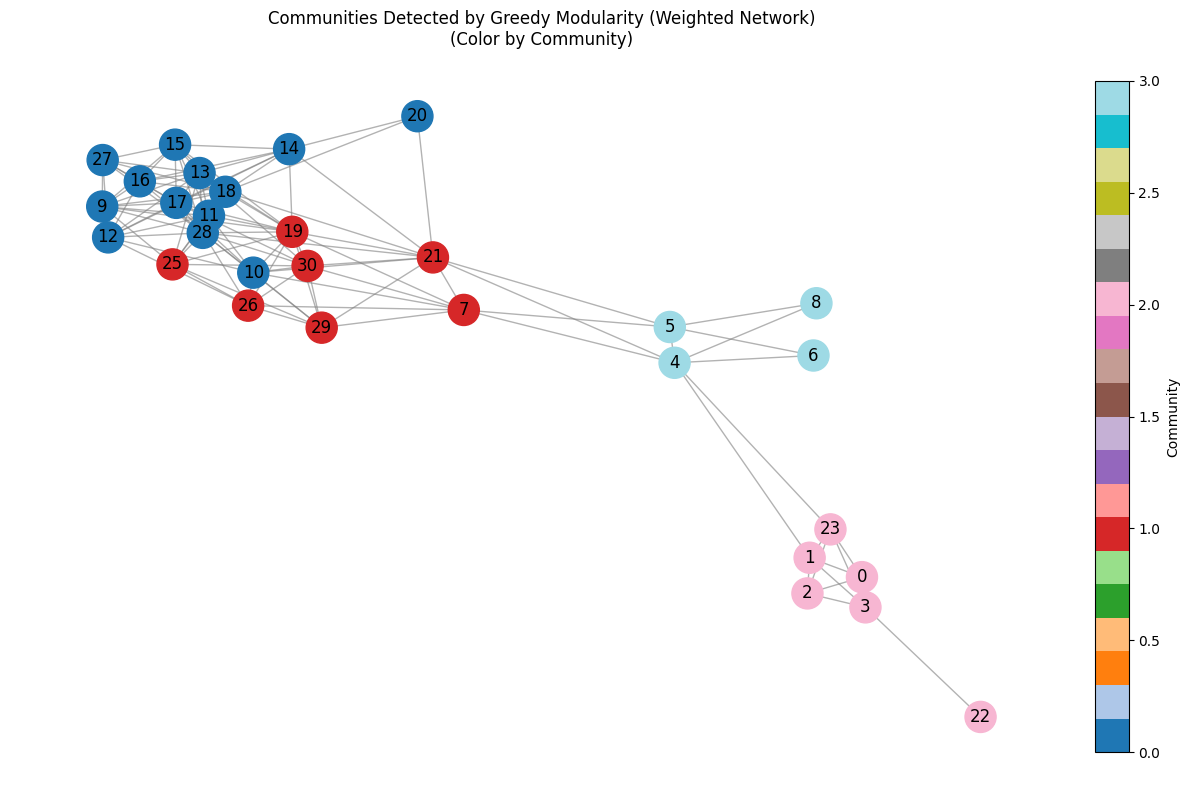

In [26]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from networkx.algorithms.community import greedy_modularity_communities, modularity

# 读取图数据（带权重）
G = nx.read_weighted_edgelist('courses2.txt')
G = G.to_undirected()

# 度中心性（基于无权重连接数，这是标准定义）
degree_centrality = nx.degree_centrality(G)

# === 使用贪心模块度最大化算法（支持权重）===
communities = list(greedy_modularity_communities(G, weight='weight'))

# 构建 community_map: node -> community_id
community_map = {}
for comm_id, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_id

# 打印基本信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 打印每个社区包含的节点
for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# 计算模块度（注意：modularity 函数也要传 weight）
modularity_value = modularity(G, communities, weight='weight')
print(f"Modularity: {modularity_value}")

# 覆盖度（Coverage）：社区内部边占总边的比例
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 表现评分（Performance）
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges_set = set(tuple(sorted(e)) for e in G.edges())
    
    # 实际内部边
    intra_edges = sum(1 for u, v in actual_edges_set if community_map[u] == community_map[v])
    inter_edges = len(actual_edges_set) - intra_edges
    
    # 可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # 正确预测 = 存在的内部边 + 不存在的外部边
    missing_inter_edges = possible_inter_edges - inter_edges
    correct_predictions = intra_edges + missing_inter_edges
    
    return correct_predictions / total_possible_edges if total_possible_edges > 0 else 0

performance_value = compute_performance(G, communities, community_map)
print(f"Performance: {performance_value}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 节点颜色按社区 ID
community_colors = [community_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Greedy Modularity (Weighted Network)\n(Color by Community)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 29

Community 0: ['14', '27', '28', '11', '17', '15', '16', '9', '25', '13', '18', '10', '20', '12']
Community 1: ['22', '2', '0', '23', '1', '3']
Community 2: ['19', '7', '26', '21', '30']
Community 3: ['6', '8', '4', '5']

Modularity: 0.4555231261154074
Coverage: 0.7840909090909091
Performance: 0.8226600985221675


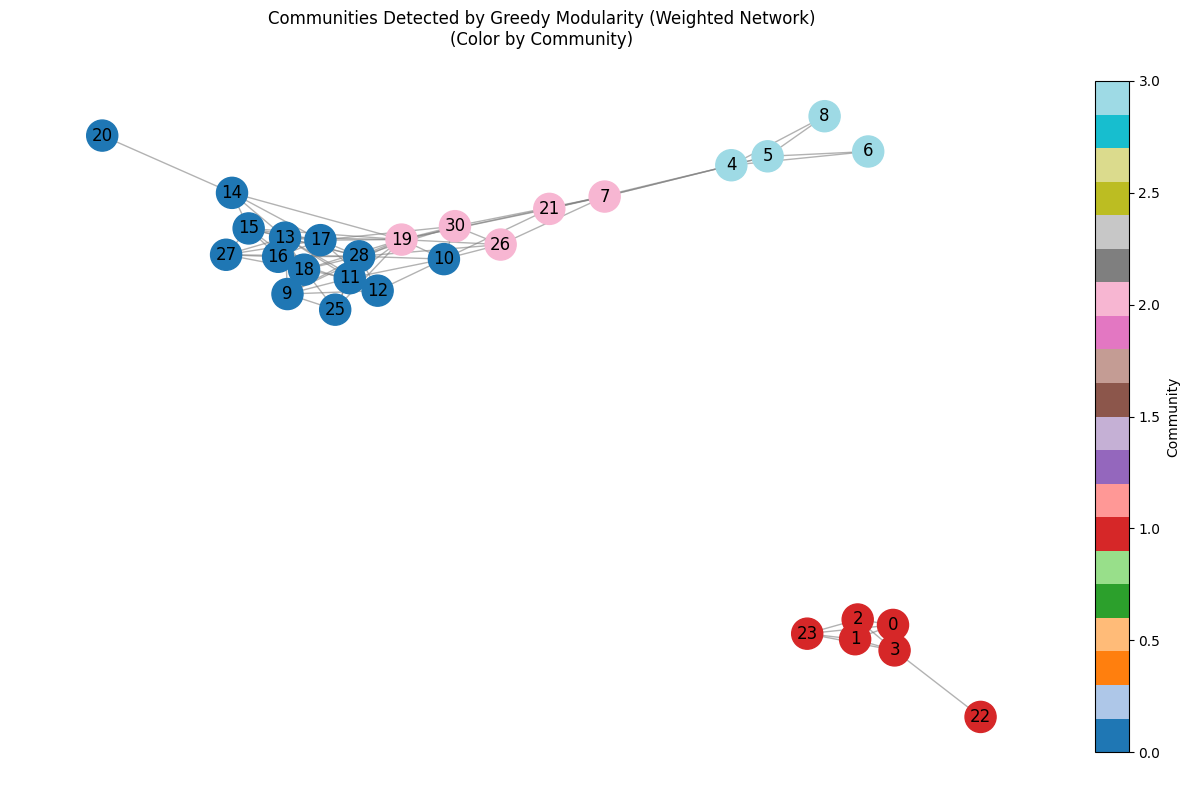

In [27]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from networkx.algorithms.community import greedy_modularity_communities, modularity

# 读取图数据（带权重）
G = nx.read_weighted_edgelist('courses3.txt')
G = G.to_undirected()

# 度中心性（基于无权重连接数，这是标准定义）
degree_centrality = nx.degree_centrality(G)

# === 使用贪心模块度最大化算法（支持权重）===
communities = list(greedy_modularity_communities(G, weight='weight'))

# 构建 community_map: node -> community_id
community_map = {}
for comm_id, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_id

# 打印基本信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 打印每个社区包含的节点
for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# 计算模块度（注意：modularity 函数也要传 weight）
modularity_value = modularity(G, communities, weight='weight')
print(f"Modularity: {modularity_value}")

# 覆盖度（Coverage）：社区内部边占总边的比例
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 表现评分（Performance）
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges_set = set(tuple(sorted(e)) for e in G.edges())
    
    # 实际内部边
    intra_edges = sum(1 for u, v in actual_edges_set if community_map[u] == community_map[v])
    inter_edges = len(actual_edges_set) - intra_edges
    
    # 可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # 正确预测 = 存在的内部边 + 不存在的外部边
    missing_inter_edges = possible_inter_edges - inter_edges
    correct_predictions = intra_edges + missing_inter_edges
    
    return correct_predictions / total_possible_edges if total_possible_edges > 0 else 0

performance_value = compute_performance(G, communities, community_map)
print(f"Performance: {performance_value}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 节点颜色按社区 ID
community_colors = [community_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Greedy Modularity (Weighted Network)\n(Color by Community)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 29

Community 0: ['12', '18', '16', '28', '17', '25', '27', '11', '13', '20', '9', '14', '10', '15']
Community 1: ['23', '3', '0', '1', '22', '2']
Community 2: ['7', '26', '30', '21', '19']
Community 3: ['4', '8', '6', '5']

Modularity: 0.4555231261154074
Coverage: 0.7840909090909091
Performance: 0.9461756373937678


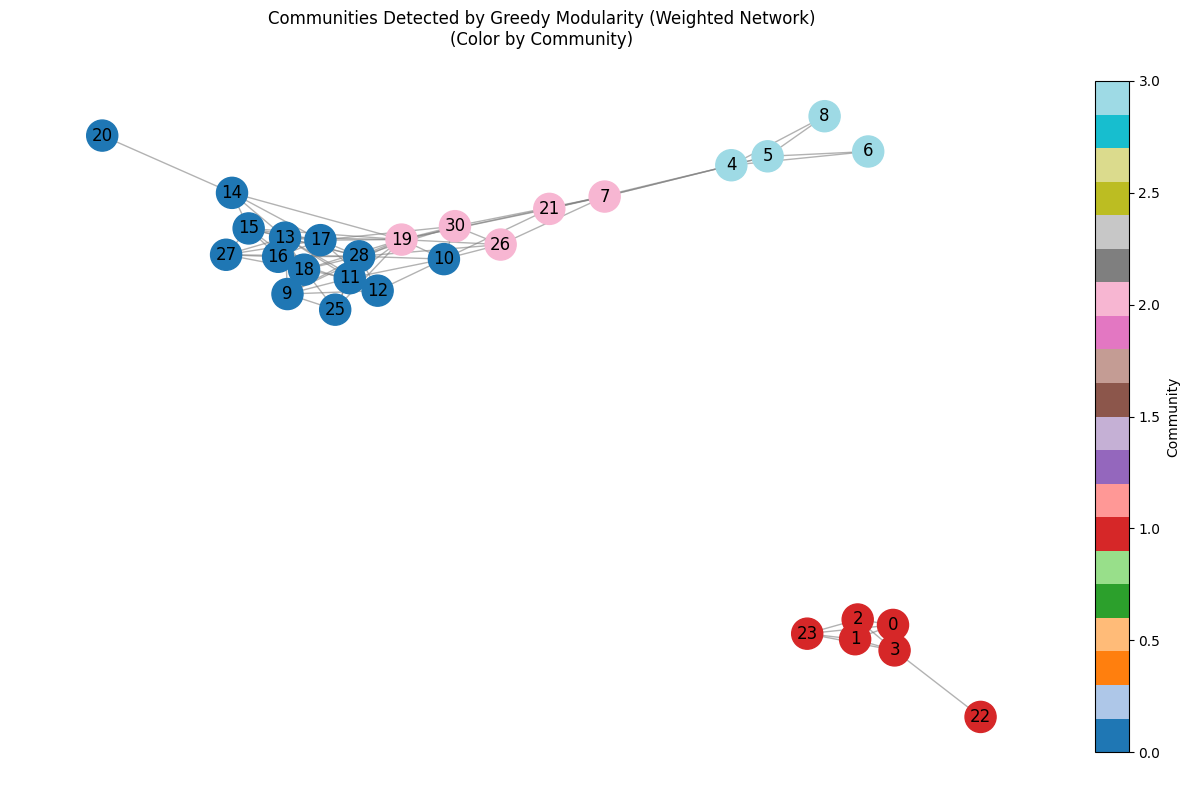

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from networkx.algorithms.community import greedy_modularity_communities, modularity

# 读取图数据（带权重）
G = nx.read_weighted_edgelist('courses3.txt')
G = G.to_undirected()

# 度中心性（基于无权重连接数，这是标准定义）
degree_centrality = nx.degree_centrality(G)

# === 使用贪心模块度最大化算法（支持权重）===
communities = list(greedy_modularity_communities(G, weight='weight'))

# 构建 community_map: node -> community_id
community_map = {}
for comm_id, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_id

# 打印基本信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 打印每个社区包含的节点
for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# 计算模块度（注意：modularity 函数也要传 weight）
modularity_value = modularity(G, communities, weight='weight')
print(f"Modularity: {modularity_value}")

# 覆盖度（Coverage）：社区内部边占总边的比例
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 手动实现表现评分
def compute_performance(G, communities):
    intra_edges = sum(1 for edge in G.edges() if community_map[edge[0]] == community_map[edge[1]])
    inter_edges = sum(1 for edge in G.edges() if community_map[edge[0]] != community_map[edge[1]])
    possible_intra_edges = sum(len(community) * (len(community) - 1) / 2 for community in communities)
    possible_inter_edges = len(G.nodes()) * (len(G.nodes()) - 1) / 2 - possible_intra_edges
    return (intra_edges + possible_inter_edges - inter_edges) / (intra_edges + inter_edges + possible_inter_edges - inter_edges)

performance_value = compute_performance(G, communities)
print(f"Performance: {performance_value}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 节点颜色按社区 ID
community_colors = [community_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Greedy Modularity (Weighted Network)\n(Color by Community)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 28

Community 0: ['14', '27', '28', '11', '17', '15', '16', '9', '25', '13', '18', '10', '20', '12']
Community 1: ['2', '0', '23', '1', '3']
Community 2: ['7', '5', '6', '8', '4']
Community 3: ['26', '21', '19', '30']

Modularity: 0.47281333242264867
Coverage: 0.8028169014084507
Performance: 0.8042328042328042


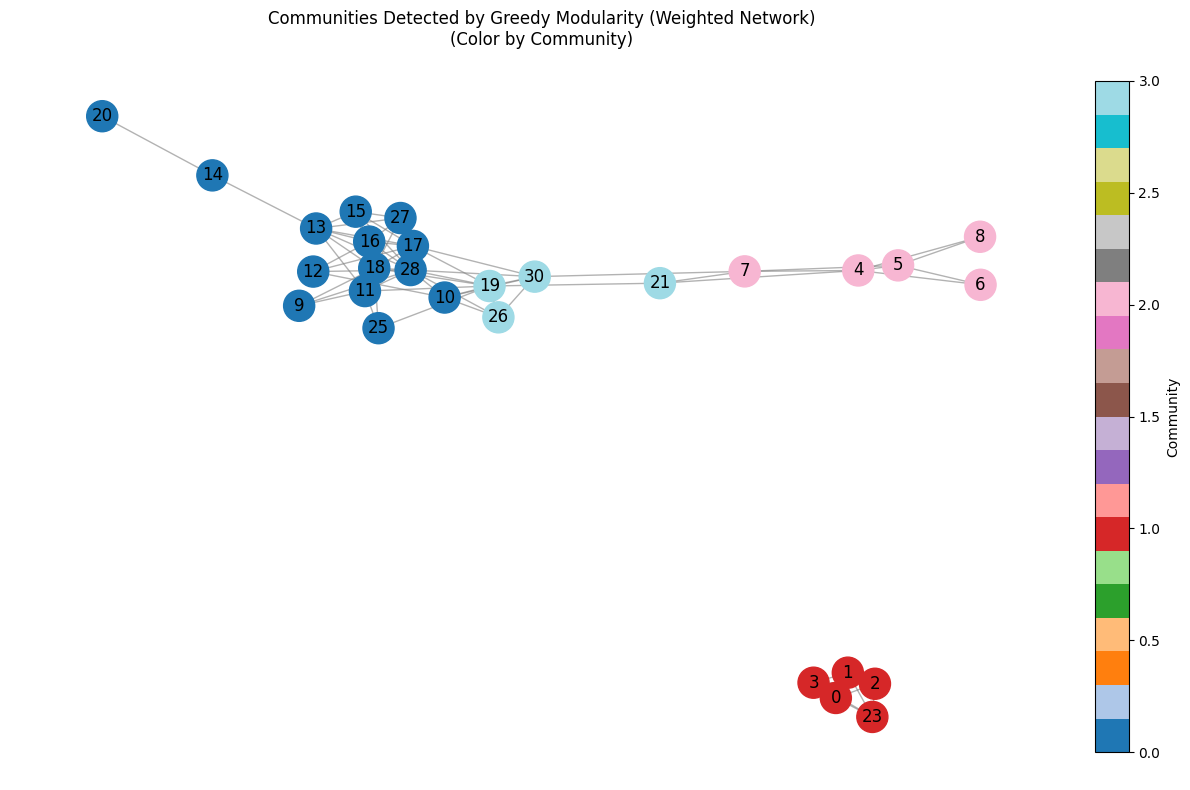

In [28]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from networkx.algorithms.community import greedy_modularity_communities, modularity

# 读取图数据（带权重）
G = nx.read_weighted_edgelist('courses4.txt')
G = G.to_undirected()

# 度中心性（基于无权重连接数，这是标准定义）
degree_centrality = nx.degree_centrality(G)

# === 使用贪心模块度最大化算法（支持权重）===
communities = list(greedy_modularity_communities(G, weight='weight'))

# 构建 community_map: node -> community_id
community_map = {}
for comm_id, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_id

# 打印基本信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 打印每个社区包含的节点
for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# 计算模块度（注意：modularity 函数也要传 weight）
modularity_value = modularity(G, communities, weight='weight')
print(f"Modularity: {modularity_value}")

# 覆盖度（Coverage）：社区内部边占总边的比例
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 表现评分（Performance）
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges_set = set(tuple(sorted(e)) for e in G.edges())
    
    # 实际内部边
    intra_edges = sum(1 for u, v in actual_edges_set if community_map[u] == community_map[v])
    inter_edges = len(actual_edges_set) - intra_edges
    
    # 可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # 正确预测 = 存在的内部边 + 不存在的外部边
    missing_inter_edges = possible_inter_edges - inter_edges
    correct_predictions = intra_edges + missing_inter_edges
    
    return correct_predictions / total_possible_edges if total_possible_edges > 0 else 0

performance_value = compute_performance(G, communities, community_map)
print(f"Performance: {performance_value}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 节点颜色按社区 ID
community_colors = [community_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Greedy Modularity (Weighted Network)\n(Color by Community)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()

Number of communities: 4
Total number of nodes (colleges): 26

Community 0: ['14', '27', '28', '11', '16', '15', '9', '17', '25', '13', '18', '10', '12']
Community 1: ['2', '0', '23', '1', '3']
Community 2: ['19', '7', '26', '21', '30']
Community 3: ['6', '4', '5']

Modularity: 0.4844353741496599
Coverage: 0.8431372549019608
Performance: 0.796923076923077


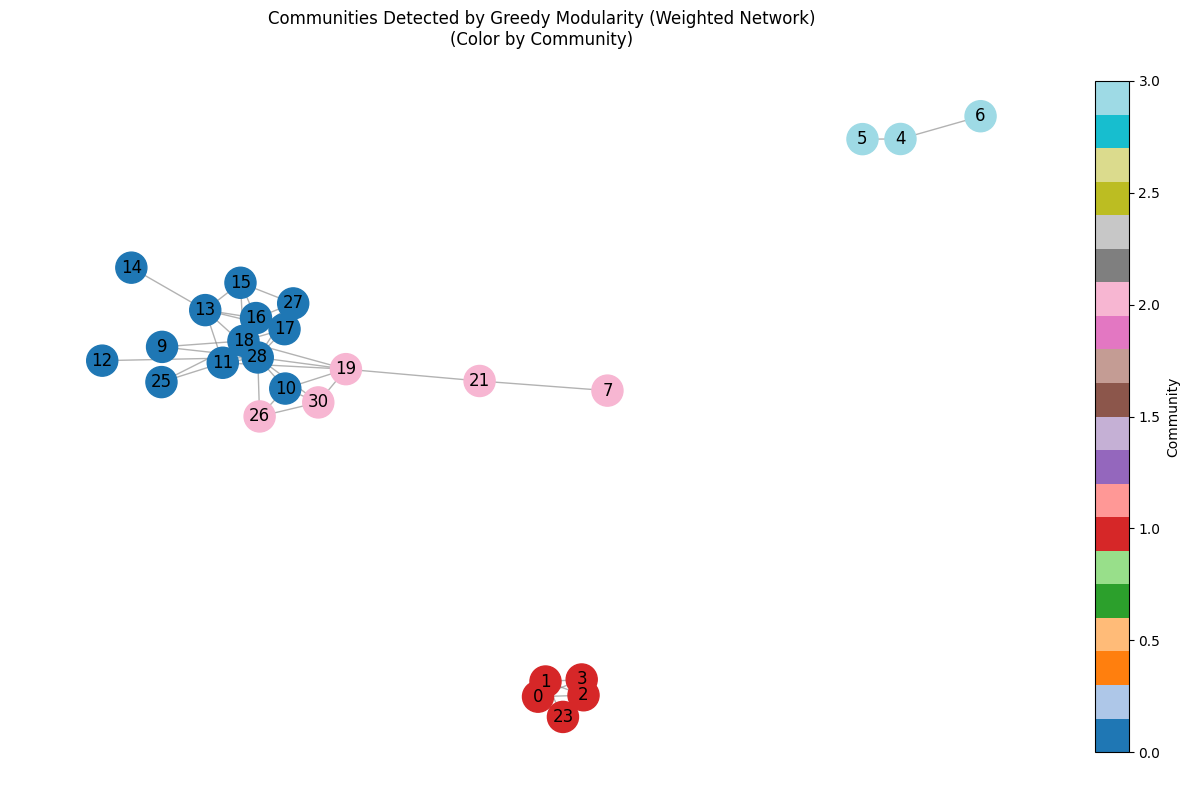

In [29]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from networkx.algorithms.community import greedy_modularity_communities, modularity

# 读取图数据（带权重）
G = nx.read_weighted_edgelist('courses5.txt')
G = G.to_undirected()

# 度中心性（基于无权重连接数，这是标准定义）
degree_centrality = nx.degree_centrality(G)

# === 使用贪心模块度最大化算法（支持权重）===
communities = list(greedy_modularity_communities(G, weight='weight'))

# 构建 community_map: node -> community_id
community_map = {}
for comm_id, community in enumerate(communities):
    for node in community:
        community_map[node] = comm_id

# 打印基本信息
num_communities = len(communities)
print(f"Number of communities: {num_communities}")

total_nodes = G.number_of_nodes()
print(f"Total number of nodes (colleges): {total_nodes}\n")

# 打印每个社区包含的节点
for comm_id, community in enumerate(communities):
    print(f"Community {comm_id}: {list(community)}")
print()

# 计算模块度（注意：modularity 函数也要传 weight）
modularity_value = modularity(G, communities, weight='weight')
print(f"Modularity: {modularity_value}")

# 覆盖度（Coverage）：社区内部边占总边的比例
def compute_coverage(G, community_map):
    intra_edges = sum(1 for u, v in G.edges() if community_map[u] == community_map[v])
    total_edges = G.number_of_edges()
    return intra_edges / total_edges if total_edges > 0 else 0

coverage_value = compute_coverage(G, community_map)
print(f"Coverage: {coverage_value}")

# 表现评分（Performance）
def compute_performance(G, communities, community_map):
    n = G.number_of_nodes()
    total_possible_edges = n * (n - 1) / 2
    actual_edges_set = set(tuple(sorted(e)) for e in G.edges())
    
    # 实际内部边
    intra_edges = sum(1 for u, v in actual_edges_set if community_map[u] == community_map[v])
    inter_edges = len(actual_edges_set) - intra_edges
    
    # 可能的内部边（各社区完全连接）
    possible_intra_edges = sum(len(c) * (len(c) - 1) / 2 for c in communities)
    possible_inter_edges = total_possible_edges - possible_intra_edges
    
    # 正确预测 = 存在的内部边 + 不存在的外部边
    missing_inter_edges = possible_inter_edges - inter_edges
    correct_predictions = intra_edges + missing_inter_edges
    
    return correct_predictions / total_possible_edges if total_possible_edges > 0 else 0

performance_value = compute_performance(G, communities, community_map)
print(f"Performance: {performance_value}")

# === 可视化 ===
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

# 节点颜色按社区 ID
community_colors = [community_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=community_colors, cmap=plt.cm.tab20, node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1, alpha=0.6)

# 颜色条
sm = ScalarMappable(
    cmap=plt.cm.tab20,
    norm=plt.Normalize(vmin=min(community_colors), vmax=max(community_colors))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Community')

plt.title('Communities Detected by Greedy Modularity (Weighted Network)\n(Color by Community)')
plt.gca().set_facecolor('white')
plt.axis('off')
plt.tight_layout()
plt.show()